# S5 — Análisis de *blobs* (manchas) en imágenes

Este cuaderno presenta técnicas para la detección, filtrado y análisis de **blobs** (manchas/objetos con forma aproximadamente circular/ellíptica) en imágenes.

## Objetivos

- Repasar la binarización (umbral fijo y Otsu) aplicada a una imagen con formas geométricas.
- Introducir los operadores morfológicos: erosión, dilatación, apertura y cierre.
- Detectar blobs con el método DoH (Determinant of Hessian) usando `blob_doh`.
- Explorar el efecto de los parámetros `threshold` y `max_sigma` sobre las detecciones.
- Comparar la detección de blobs sobre la imagen en escala de grises frente a versiones binarizadas.

### Requisitos

- Bibliotecas del worksheet anterior (scikit-image, numpy, matplotlib, etc.).
- `ipywidgets` (para controles interactivos).

> Nota: después de instalar paquetes nuevos, reiniciar el kernel para que los cambios se apliquen.

In [ ]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage import data, io, filters
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu

from ipywidgets import interactive, IntSlider, FloatSlider

## Imagen de trabajo

Comenzamos cargando la imagen con la que trabajaremos durante la primera parte del notebook. Se trata de una imagen sintética con figuras geométricas de distintos colores sobre fondo blanco. La hemos elegido porque:

- Tiene bordes bien definidos → es fácil entender el efecto de los filtros.
- Contiene figuras de distintos tamaños y formas → podemos explorar los límites de los métodos.
- Sirve como pregunta motivadora: **¿podríamos contar automáticamente cuántas figuras hay?**

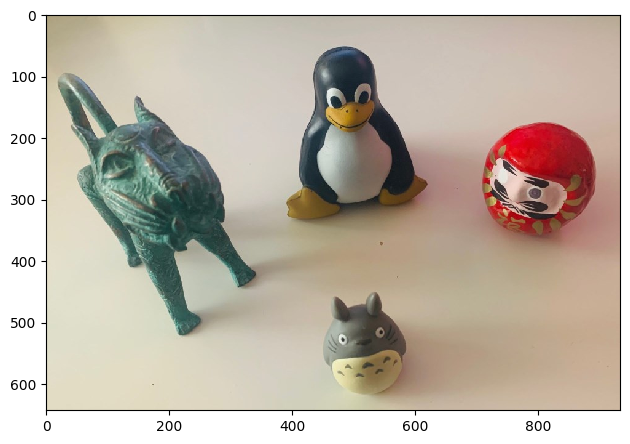

In [ ]:
img_path = 'img/figuras.jpg'
img = io.imread(img_path)
io.imshow(img)
io.show()

## Binarización

Otros filtros clásicos son los filtros de binarización. Estos filtros convierten una imagen en escala de grises en una imagen **monocroma** (blanco y negro).

<div style="background-color:#FFFFCC; padding: 10px; margin:10px; border-radius:10px">
⚠️ La mayor parte de la gente cuando habla de una imagen en blanco y negro se refiere a una imagen en escala de grises. En visión por computador, cuando hablamos de blanco y negro nos referimos a <b>monocromo</b>: una imagen cuyos únicos valores son 0 (negro) o 1 (blanco).
</div>

### Umbral fijo

El filtro más **básico** de binarización es el **umbral fijo**. Dado un valor de corte, cada píxel se convierte en 1 si supera el umbral y en 0 si no lo supera:

$$
\text{resultado}(x,y) = \begin{cases} 1 & \text{si } pixel(x,y) > umbral \\ 0 & \text{si } pixel(x,y) \leq umbral \end{cases}
$$

Una implementación de este algoritmo en NumPy es la siguiente (aprovecha que una comparación booleana ya devuelve un array de `True`/`False`):

In [ ]:
def umbral_fijo(img, umbral):
    """Binariza una imagen en escala de grises a partir de un umbral"""
    return img > umbral

La binarización se aplica sobre una imagen en **escala de grises** (un solo canal de intensidad, valores en [0, 1]). Primero convertimos la imagen RGB con `rgb2gray` y a continuación aplicamos el umbral fijo:

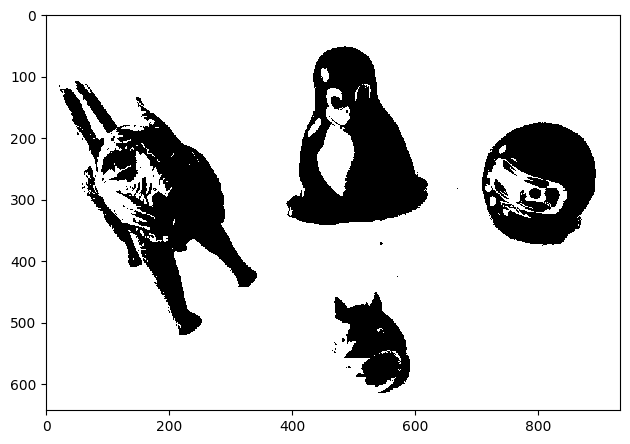

In [ ]:
img_gray = rgb2gray(img)
img_mono = umbral_fijo(img_gray, 0.5)
#io.imshow(img_mono)
io.imshow(img_mono.astype(float), cmap=plt.cm.gray)
io.show()

Podemos verificar que la imagen binarizada contiene únicamente dos valores (0 y 1) y que su tipo de dato es booleano:

In [ ]:
print("dtype          :", img_mono.dtype)
print("valores únicos :", np.unique(img_mono))
print("dimensiones    :", img_mono.shape)

dtype          : bool
valores únicos : [False  True]
dimensiones    : (643, 934)


Podemos jugar con los distintos umbrales del filtro:

In [ ]:
def filter_binarization(value):
    io.imshow(umbral_fijo(img_gray, value).astype(float), cmap=plt.cm.gray)
    io.show()

slider = FloatSlider(min=0, max=1, step=0.05, value=0.5, continuous_update=False)
interactive(filter_binarization, value=slider)

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='value', max=1.0, step=0.05)…

### Algoritmo de Otsu

El algoritmo de Otsu (https://es.wikipedia.org/wiki/M%C3%A9todo_del_valor_umbral#M%C3%A9todo_de_Otsu) nos proporciona una forma automatizada de obtener el umbral de binarización basado en un análisis estadístico.

El algoritmo se basa en utilizar como umbral de corte el punto máximo en el que la variación interna entre clases es máxima:

<center>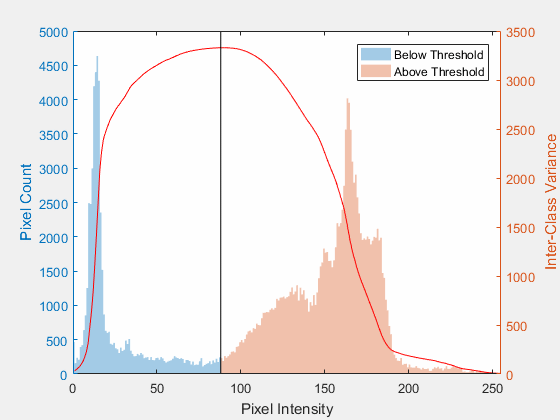</center>

Piénsalo de la siguiente manera, encontrar el punto de corte óptimo es encontrar el punto en el que las dos distribuciones: blanco y negro se maxima la diferencia entre ellas a la vez que se minimiza la variación interna.

En `sklearn` este algoritmo está dispone como `threshold_otsu` y podemos utilizarlo de la siguiente forma:

In [ ]:
umbral_otsu = threshold_otsu(img_gray)
umbral_otsu

np.float64(0.5279937522977942)

Una vez calculado podemos aplicarlo con el mismo método anterior:

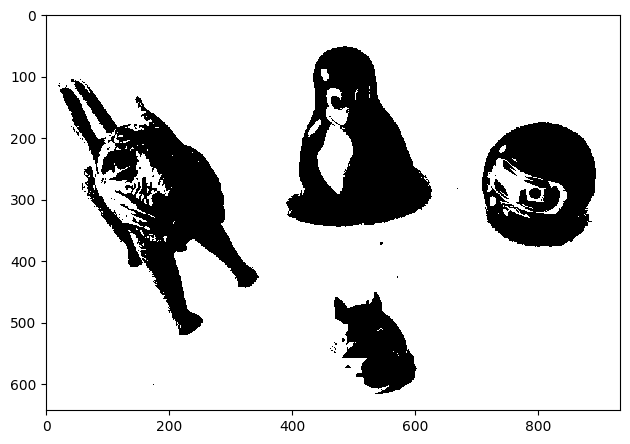

In [ ]:
img_mono = umbral_fijo(img_gray, umbral_otsu)
io.imshow(img_mono.astype(float), cmap=plt.cm.gray)
io.show()

### Preguntas

* ¿Piensas que es posible encontrar un umbral que segmente perfectamente las figuras anteriores?
* ¿Crees que el algoritmo de Otsu nos proporcionaría ese umbral?

## Operadores morfológicos

Como hemos visto, es muy **difícil** encontrar un único umbral que segmente perfectamente una imagen real: siempre aparecen pequeños agujeros dentro de los objetos, ruido en el fondo o bordes irregulares.

Los **operadores morfológicos** son filtros que modifican la forma de las regiones binarias sin necesidad de conocer los valores de intensidad originales. Son el complemento natural de la binarización: primero umbralamos y luego usamos morfología para "limpiar" el resultado.

Los cuatro operadores básicos:

| Operador | Operación | Efecto principal |
|----------|-----------|-----------------|
| Erosión $\ominus$ | AND del SE con cada ventana | Encoge objetos, elimina detalles pequeños |
| Dilatación $\oplus$ | OR del SE con cada ventana | Agranda objetos, une partes cercanas |
| Apertura $\circ$ | Erosión → Dilatación | Elimina objetos/ruido pequeños |
| Cierre $\bullet$ | Dilatación → Erosión | Rellena agujeros pequeños |

Todos ellos se aplican con un **elemento estructurante** (SE) que actúa como "sello" y determina la forma y tamaño de la transformación.

### Erosión $\ominus$

El operador erosión desplaza el SE por cada píxel de la imagen y pone el resultado a 1 **solo si todos los píxeles bajo el SE son 1** (AND lógico). Si alguno es 0, el resultado es 0.

Supongamos que tenemos una imagen con la figura de la izquierda y un elemento estructurante (otra matriz) como la figura de la derecha:
<pre>
    1 1 1 1 1 1 1 1 1 1 1 1 1
    1 1 1 1 1 1 0 1 1 1 1 1 1
    1 1 1 1 1 1 1 1 1 1 1 1 1
    1 1 1 1 1 1 1 1 1 1 1 1 1
    1 1 1 1 1 1 1 1 1 1 1 1 1
    1 1 1 1 1 1 1 1 1 1 1 1 1               1 1 1
    1 1 1 1 1 1 1 1 1 1 1 1 1               1 1 1
    1 1 1 1 1 1 1 1 1 1 1 1 1               1 1 1
    1 1 1 1 1 1 1 1 1 1 1 1 1
    1 1 1 1 1 1 1 1 1 1 1 1 1
    1 1 1 1 1 1 1 1 1 1 1 1 1
    1 1 1 1 1 1 1 1 1 1 1 1 1
    1 1 1 1 1 1 1 1 1 1 1 1 1
</pre>

El resultado tras aplicar la erosión es:

<pre>
    0 0 0 0 0 0 0 0 0 0 0 0 0
    0 1 1 1 1 0 0 0 1 1 1 1 0
    0 1 1 1 1 0 0 0 1 1 1 1 0
    0 1 1 1 1 1 1 1 1 1 1 1 0
    0 1 1 1 1 1 1 1 1 1 1 1 0
    0 1 1 1 1 1 1 1 1 1 1 1 0
    0 1 1 1 1 1 1 1 1 1 1 1 0
    0 1 1 1 1 1 1 1 1 1 1 1 0
    0 1 1 1 1 1 1 1 1 1 1 1 0
    0 1 1 1 1 1 1 1 1 1 1 1 0
    0 1 1 1 1 1 1 1 1 1 1 1 0
    0 1 1 1 1 1 1 1 1 1 1 1 0
    0 0 0 0 0 0 0 0 0 0 0 0 0
</pre>

[Mathematical morphology: erosion](https://www.youtube.com/watch?v=b5lgnNEzGeU)

El elemento estructurante no tiene por qué ser un cuadrado; puede tener cualquier forma como podemos ver en la siguiente figura:

Podemos aplicar este operador en `skimage` de la siguiente manera:

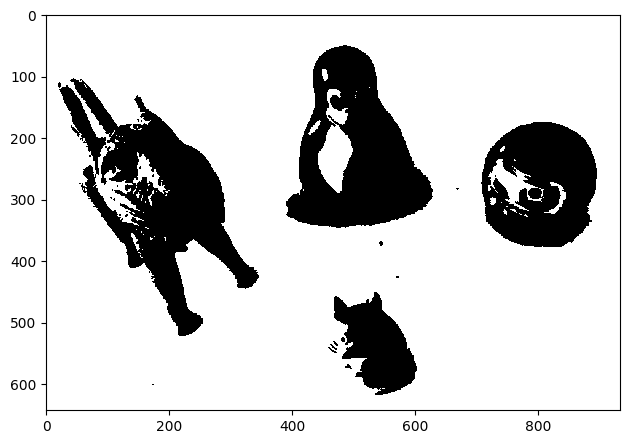

In [ ]:
from skimage.morphology import erosion

io.imshow(erosion(img_mono).astype(float), cmap=plt.cm.gray)
io.show()

A la función anterior (`erosion`) le podemos pasar como parámetro opcional el elemento estructurante que podemos crear manualmente o con varias funciones predefinidas:

In [ ]:
from skimage.morphology import square

print("{}\n".format(square(1)))
print("{}\n".format(square(2)))
print("{}\n".format(square(3)))

[[1]]

[[1 1]
 [1 1]]

[[1 1 1]
 [1 1 1]
 [1 1 1]]



In [ ]:
from skimage.morphology import disk

print("{}\n".format(disk(1)))
print("{}\n".format(disk(2)))
print("{}\n".format(disk(3)))

[[0 1 0]
 [1 1 1]
 [0 1 0]]

[[0 0 1 0 0]
 [0 1 1 1 0]
 [1 1 1 1 1]
 [0 1 1 1 0]
 [0 0 1 0 0]]

[[0 0 0 1 0 0 0]
 [0 1 1 1 1 1 0]
 [0 1 1 1 1 1 0]
 [1 1 1 1 1 1 1]
 [0 1 1 1 1 1 0]
 [0 1 1 1 1 1 0]
 [0 0 0 1 0 0 0]]



In [ ]:
def filter_erosion(value):
    io.imshow(erosion(img_mono, disk(value)).astype(float), cmap=plt.cm.gray)
    io.show()

slider = IntSlider(min=1, max=32, step=1, value=1, continuous_update=False)
interactive(filter_erosion, value=slider)

interactive(children=(IntSlider(value=1, continuous_update=False, description='value', max=32, min=1), Output(…

### Dilatación $\oplus$

La dilatación ($\oplus$) es el efecto opuesto a la erosión. Recorremos la imagen con el elemento estructurante y marcamos el pixel como 1 si alguno de los elementos coincide.

<center>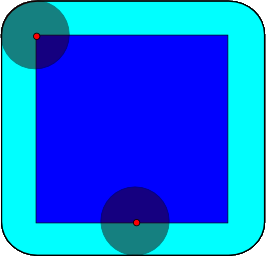</center>


[Mathematical morphology: dilation](https://www.youtube.com/watch?v=3IJ8RFtlDLY)

Podemos ver como funciona en la siguiente demo:

In [ ]:
from skimage.morphology import dilation

def filter_dilation(value):
    io.imshow(dilation(img_mono, disk(value)).astype(float), cmap=plt.cm.gray)
    io.show()

slider = IntSlider(min=1, max=32, step=1, value=1, continuous_update=False)
interactive(filter_dilation, value=slider)

interactive(children=(IntSlider(value=1, continuous_update=False, description='value', max=32, min=1), Output(…

### Apertura $\circ$

Es el efecto de aplicar una erosión y después una dilatación

$$ A\circ B=(A\ominus B)\oplus B $$

Podemos ver como funciona. Al aplicar el elemento estructurante (circulo) sobre un cuadrado (azul oscuro) obtenemos un cuadrado con bordes redondeados (azul celeste):

<center>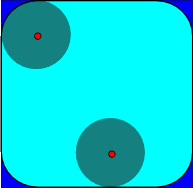</center>

Este filtro **elimina objetos y ruido pequeños** (más pequeños que el elemento estructurante) y **suaviza los bordes** de los objetos grandes. Útil para quitar imperfecciones de una máscara binaria.

In [ ]:
from skimage.morphology import opening

def filter_opening(value):
    io.imshow(opening(img_mono, disk(value)).astype(float), cmap=plt.cm.gray)
    io.show()

slider = IntSlider(min=1, max=64, step=1, value=1, continuous_update=False)
interactive(filter_opening, value=slider)

interactive(children=(IntSlider(value=1, continuous_update=False, description='value', max=64, min=1), Output(…

### Cierre $\bullet$

La función cierre consiste en aplicar una dilatación y posteriormente una erosión:

$$A\bullet B=(A\oplus B)\ominus B.$$

Este filtro **rellena pequeños agujeros** dentro de los objetos y **une partes cercanas** que hayan quedado separadas. Útil para cerrar brechas en contornos o recuperar píxeles perdidos:

<center>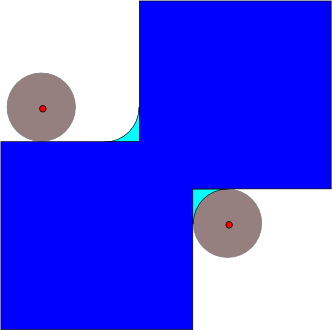</center>

In [ ]:
from skimage.morphology import closing

def filter_closing(value):
    io.imshow(closing(img_mono, disk(value)).astype(float), cmap=plt.cm.gray)
    io.show()

slider = IntSlider(min=1, max=64, step=1, value=12, continuous_update=False)
interactive(filter_closing, value=slider)

interactive(children=(IntSlider(value=12, continuous_update=False, description='value', max=64, min=1), Output…

### Preguntas

* ¿Para qué nos pueden valer los operadores morfológicos?
* ¿Qué combinación de operadores usarías para aislar mejor las figuras de `figuras.jpg` después de binarizarla? Pruébalo.

## Análisis de blobs

Los operadores morfológicos nos ayudan a limpiar imágenes binarias. Pero existe otra familia de métodos pensados directamente para **detectar regiones compactas en la imagen original**: los **detectores de blobs**.

Un **blob** (del inglés *Binary Large Object*, o simplemente "mancha") es una región de la imagen donde los píxeles comparten alguna propiedad —intensidad, color, textura— y están agrupados de forma compacta. En la práctica suelen corresponder a objetos con forma aproximadamente circular o elíptica.

Vamos a cargar una fotografía del espacio profundo (Hubble Deep Field) para identificar las estrellas y galaxias que aparecen:

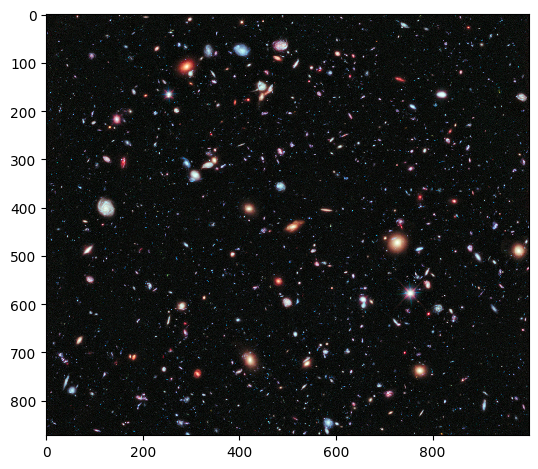

In [ ]:
from skimage.data import hubble_deep_field

hubble = hubble_deep_field()
io.imshow(hubble)
io.show()

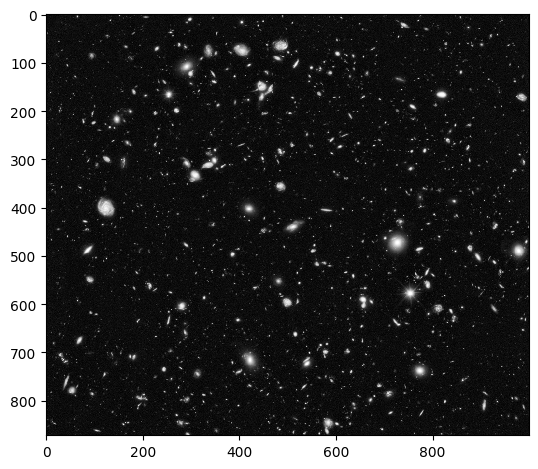

In [ ]:
hubble_gray = rgb2gray(hubble)
io.imshow(hubble_gray)
io.show()

### Primer intento: ¿podemos contar estrellas con binarización?

Antes de aplicar el detector de blobs, intentemos con la técnica que ya conocemos: binarizar la imagen con un umbral fijo de 0.5. ¿Sería fácil contar los objetos celestes en el resultado?

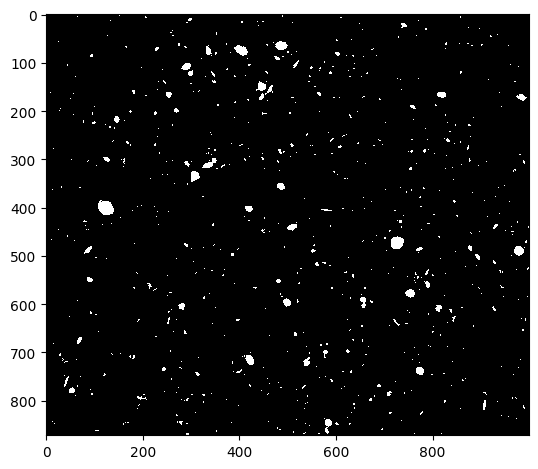

In [ ]:
io.imshow(umbral_fijo(hubble_gray, 0.5).astype(float), cmap=plt.cm.gray)
io.show()

Cada **blob** detectado corresponde a una estrella u otro objeto celeste visible en la imagen.

Supongamos que queremos **contar cuántas estrellas aparecen**. Hacerlo a mano es inviable: la imagen contiene cientos de objetos. Los detectores de blobs automatizan esta tarea.

`skimage` ofrece tres detectores principales:

| Método | Nombre completo | Velocidad | Notas |
|--------|----------------|-----------|-------|
| `blob_log` | Laplacian of Gaussian | Lento | Alta precisión |
| `blob_dog` | Difference of Gaussians | Rápido | Buena aproximación a LoG |
| `blob_doh` | Determinant of Hessian | Muy rápido | Invariante a escala |

Usaremos `blob_doh` por su velocidad. El método analiza la **matriz hessiana** de la imagen convolucionada con gaussianas a distintas escalas y detecta las regiones donde hay una curvatura marcada en todas las direcciones.

> **Nota:** `blob_doh` está marcada como deprecada en versiones recientes de scikit-image (≥0.19). Para código en producción se recomienda `blob_log` (Laplacian of Gaussian) o `blob_dog` (Difference of Gaussians). En este cuaderno la usamos por su simplicidad conceptual.

In [ ]:
from skimage.feature import blob_doh
blobs = blob_doh(hubble_gray, max_sigma=10, threshold=0.015)

La función devuelve un array donde **cada fila es un blob detectado** con tres valores:

| Columna | Variable | Significado |
|---------|----------|-------------|
| 0 | `y` | Coordenada vertical del centro (fila) |
| 1 | `x` | Coordenada horizontal del centro (columna) |
| 2 | `r` | Radio aproximado (proporcional a la escala de detección) |

A mayor `r`, más grande es el blob detectado.

In [ ]:
blobs

array([[661., 515.,   5.],
       [596., 498.,  10.],
       [199., 269.,   6.],
       [735., 243.,   5.],
       [166., 818.,  10.],
       [ 80., 602.,   5.],
       [556., 523.,   3.],
       [496., 385.,   5.],
       [684., 567.,   3.],
       [282., 783.,   4.],
       [ 10., 297.,   4.],
       [356., 484.,  10.],
       [333., 307.,  10.],
       [604., 280.,   9.],
       [128., 389.,   3.],
       [682., 580.,   3.],
       [171., 984.,  10.],
       [110., 548.,   4.],
       [848., 601.,   4.],
       [ 16., 404.,   4.],
       [541., 635.,   4.],
       [829., 269.,   3.],
       [283., 756.,   4.],
       [172., 509.,   3.],
       [166., 253.,   8.],
       [587., 327.,   4.],
       [699., 577.,   6.],
       [590., 655.,   7.],
       [483., 876.,   7.],
       [217., 146.,   8.],
       [560., 789.,   8.],
       [667., 226.,   2.],
       [477., 554.,   3.],
       [233., 131.,   3.],
       [779.,  53.,   8.],
       [260., 831.,   6.],
       [549.,  90.,   8.],
 

Mediante la siguiente función podemos dibujarlos junto a la imagen original.

In [ ]:
def mostrar_blobs(img, blobs):
    fig, ax = plt.subplots()
    ax.imshow(img, cmap=plt.cm.gray)

    for blob in blobs:
        y, x, r = blob
        c = plt.Circle((x, y), r, color='#FFFF00AA', linewidth=2, fill=False)
        ax.add_artist(c)

    plt.show()

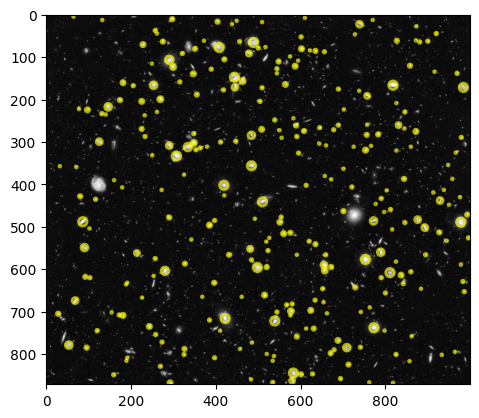

In [ ]:
mostrar_blobs(hubble_gray, blobs)

In [ ]:
print("{} estrellas.".format(len(blobs)))

284 estrellas.


Podemos ajustar dos parámetros clave para controlar las detecciones:

- **`max_sigma`** — escala máxima de búsqueda. Cuanto mayor sea su valor, más grandes pueden ser los blobs detectados. Si lo reducimos, los objetos grandes quedan sin detectar.
- **`threshold`** — sensibilidad del detector. Valores bajos detectan más blobs (incluyendo posibles falsos positivos); valores altos solo retienen los más prominentes (curvatura más fuerte).

Experimenta con el widget interactivo para ver el efecto de cada parámetro:

In [ ]:
def filter_blobs(threshold, max_sigma):
    blobs = blob_doh(hubble_gray, max_sigma=max_sigma, threshold=threshold)
    mostrar_blobs(hubble, blobs)

slider_threshold = FloatSlider(min=0, max=0.05, step=0.01, value=0.01, continuous_update=False)
slider_sigma = FloatSlider(min=1, max=60, step=1, value=30, continuous_update=False)

interactive(filter_blobs, threshold=slider_threshold, max_sigma=slider_sigma)

interactive(children=(FloatSlider(value=0.01, continuous_update=False, description='threshold', max=0.05, step…

Las técnicas de detección de blobs son ampliamente usadas, desde el ejemplo de contar estrellas, a contar células en imágenes de laboratorio a contar posibles fallos en el material en un entorno industrial.

### ¿Qué ocurre si aplicamos blob_doh sobre una imagen binarizada?

Hasta ahora hemos aplicado la detección sobre la imagen en escala de grises. Vamos a explorar qué sucede si primero binarizamos la imagen (con umbral fijo 0.5) y luego aplicamos el detector de blobs.

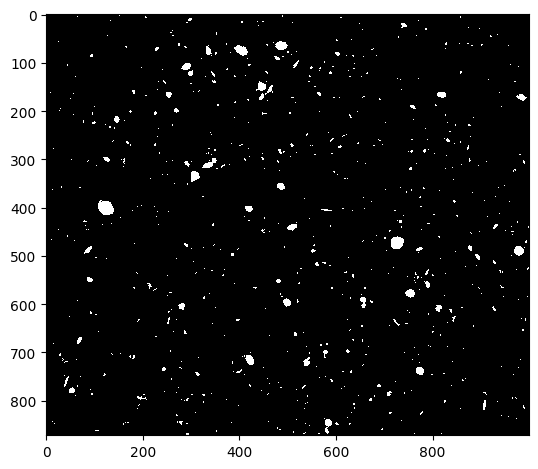

In [ ]:
hubble_mono = umbral_fijo(hubble_gray, 0.5)

io.imshow(hubble_mono.astype(float), cmap=plt.cm.gray)
io.show()

In [ ]:
blobs = blob_doh(hubble_mono, max_sigma=10, threshold=0.015)

In [ ]:
blobs

array([[552., 480.,   5.],
       [109., 548.,   3.],
       [483., 877.,   6.],
       ...,
       [302., 159.,   5.],
       [391., 126.,   9.],
       [210., 628.,   5.]], shape=(1056, 3))

In [ ]:
len(blobs)

1056

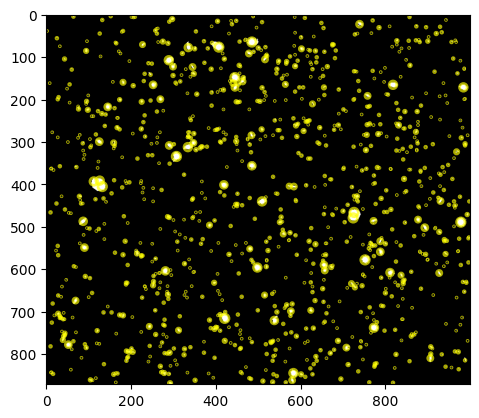

In [ ]:
mostrar_blobs(hubble_mono, blobs)

### Comparación con umbralización Otsu

El umbral fijo de 0.5 puede no ser óptimo para todas las imágenes. Repetimos la detección usando el umbral de Otsu, que se calcula automáticamente a partir del histograma de la imagen.

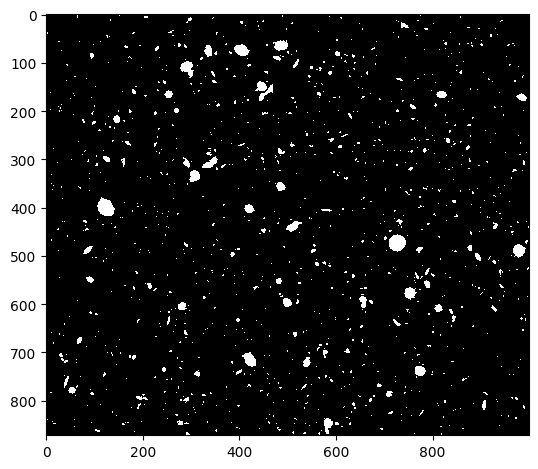

In [ ]:
umbral_otsu_hubble = threshold_otsu(hubble_gray)

hubble_mono_otsu = umbral_fijo(hubble_gray, umbral_otsu_hubble)

io.imshow(hubble_mono_otsu.astype(float), cmap=plt.cm.gray)
io.show()

In [ ]:
blobs = blob_doh(hubble_mono_otsu, max_sigma=10, threshold=0.015)
len(blobs)

1679

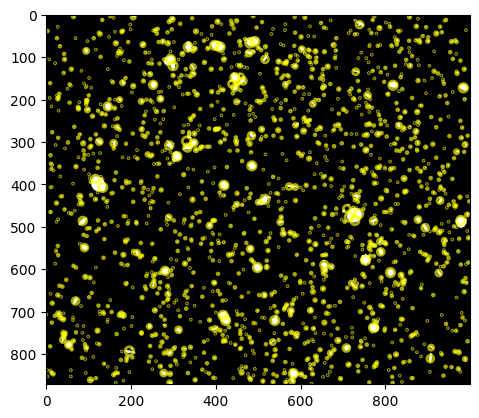

In [ ]:
mostrar_blobs(hubble_mono_otsu, blobs)

2398 blobs detectados.


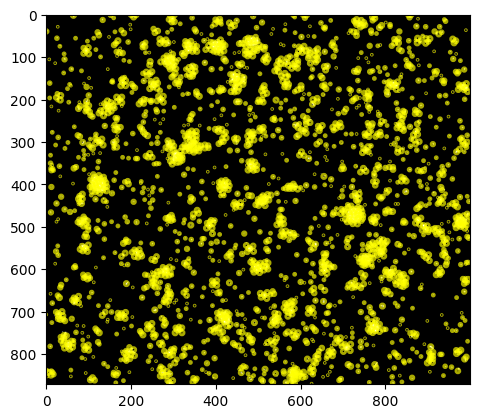

In [ ]:
blobs = blob_doh(hubble_mono_otsu, max_sigma=5, threshold=0.0005)
print("{} blobs detectados.".format(len(blobs)))
mostrar_blobs(hubble_mono_otsu, blobs)

### Conclusión

- Aplicar `blob_doh` directamente sobre la imagen en **escala de grises** suele dar mejores resultados que sobre una imagen binarizada, ya que el detector aprovecha la información de gradiente continua.
- El umbral de Otsu binariza de forma más precisa que un umbral fijo de 0.5, lo que se refleja en una ligera mejora en las detecciones.
- Los parámetros `max_sigma` (tamaño máximo de blob) y `threshold` (sensibilidad) permiten ajustar finamente qué objetos se detectan.